In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

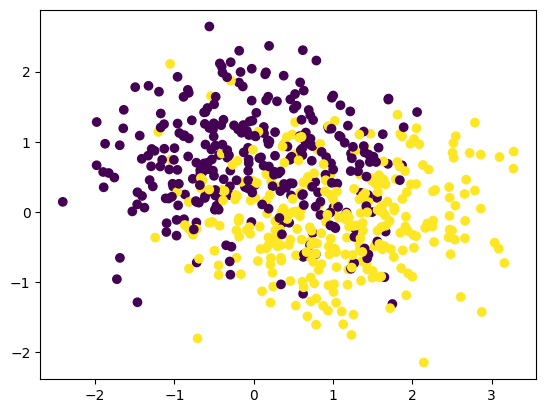

In [29]:
from sklearn.datasets import make_moons
x,y = make_moons(n_samples=600, noise=0.6, random_state=42)
plt.scatter(x[:,0], x[:,1], c=y)
plt.show()

In [30]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree (with depth)': DecisionTreeClassifier(max_depth=5),
    'Decision Tree': DecisionTreeClassifier()
}

for name,model in models.items():
  model.fit(x_train,y_train)
  Training_Acc= accuracy_score(y_train,model.predict(x_train))
  Test_Acc= accuracy_score(y_test,model.predict(x_test))

  print(f"\n----{name}-----\n")
  print(f'Training accuracy: {Training_Acc:.3f}')
  print(f'Testing accuracy: {Test_Acc:.3f}')


----Logistic Regression-----

Training accuracy: 0.790
Testing accuracy: 0.758

----Decision Tree (with depth)-----

Training accuracy: 0.848
Testing accuracy: 0.725

----Decision Tree-----

Training accuracy: 1.000
Testing accuracy: 0.733


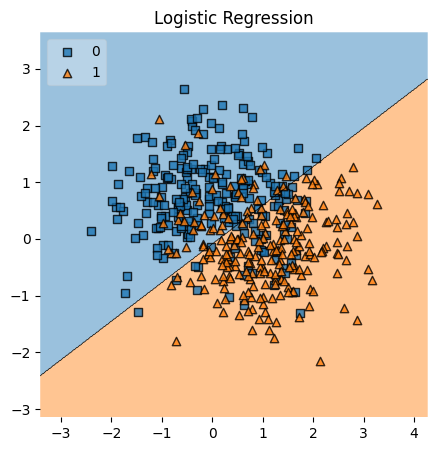

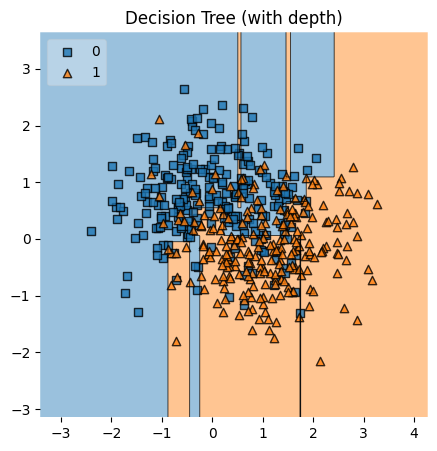

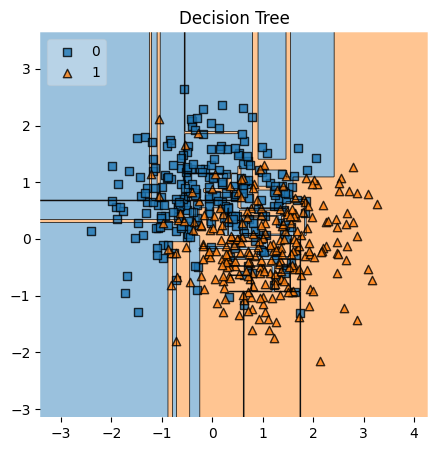

In [31]:
from mlxtend.plotting import plot_decision_regions
for name, model in models.items():
  model.fit(x_train,y_train)
  plt.figure(figsize=(5,5))
  plot_decision_regions(x_train,y_train, clf=model, legend=2)
  plt.title(name)
  plt.show()


In [32]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():
  score = cross_val_score(model, x_train, y_train, cv=12)
  print(f"{name}'s Accuracy is: {score.mean():.3f}")


Logistic Regression's Accuracy is: 0.783
Decision Tree (with depth)'s Accuracy is: 0.775
Decision Tree's Accuracy is: 0.706


In [33]:
#Self study


from sklearn.datasets import load_digits
import time
x1,y1 = load_digits(return_X_y=True)

linReg = LogisticRegression(max_iter=1000)

from sklearn.model_selection import train_test_split, cross_val_score,KFold, StratifiedKFold

#For TTS
start = time.perf_counter()
x1_train, x1_test, y1_train, y1_test = train_test_split(x1, y1, test_size=0.2, random_state=42)
linReg.fit(x1_train,y1_train)
y1_pred = linReg.predict(x1_test)
tts_time = time.perf_counter() - start

#CV
start = time.perf_counter()
cv_score = cross_val_score(linReg, x1, y1, cv=10)
cv_time = time.perf_counter() - start

#Kfold
start = time.perf_counter()
kf = KFold(n_splits=10, shuffle=True, random_state=42)
cv_score_kf = cross_val_score(linReg, x1, y1, cv=kf).mean()
kf_time = time.perf_counter() - start

#Stratified
SKfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
start = time.perf_counter()
cv_score_skf = cross_val_score(linReg, x1, y1, cv=SKfold).mean()
skf_time = time.perf_counter() - start

In [34]:
print(f"TTS Accuracy:{accuracy_score(y1_test,y1_pred):.3f} | TTS_Time: {tts_time:.3f}")
print(f"CV Score:{score.mean():.3f} | CV Time: {cv_time:.3f}")
print(f"KFold Score:{cv_score_kf:.3f} | KFold Time: {kf_time:.3f}")
print(f"Stratified Score:{cv_score_skf:.3f} | Stratified Time: {skf_time:.3f}")

TTS Accuracy:0.975 | TTS_Time: 3.275
CV Score:0.706 | CV Time: 9.143
KFold Score:0.962 | KFold Time: 12.183
Stratified Score:0.966 | Stratified Time: 13.296
